# EuroSAT — Multi-Model Training, Locked Test, and XAI (Kaggle-ready)

**This rewrite fixes a number of correctness bugs in the previous version.** The most important fix is that the test set is no longer used during training. The previous loop evaluated `test_loader` every epoch and used it for early stopping / best-checkpoint selection, which is test-set leakage and makes the reported scores optimistic.

**Stability fix (CUDA illegal memory access).** Earlier multi-GPU runs on Kaggle's dual-T4 crashed with `AcceleratorError: CUDA error: an illegal memory access was encountered` inside `scaler.scale(loss).backward()`. The cause was `nn.DataParallel` combined with AMP + SE/SiLU custom blocks — a well-known unstable combination that PyTorch itself deprecates in favour of `DistributedDataParallel`. The training loop now runs on a single primary GPU (the second T4 is left idle), uses the modern `torch.amp` API, and adds extra defensive cleanup. This eliminates the crash without hurting accuracy (a 5.5M-param CNN at 224×224 fits comfortably on one T4).

## What's done in this notebook

- Auto-detect Kaggle dataset under `/kaggle/input` plus `train.csv` / `test.csv`.
- Stratified **train / val** split from `train.csv` (deterministic seed).
- A single model — `CustomEuroSATCNN` — trained, evaluated and explained end-to-end.
- Dual-T4 via `nn.DataParallel` (also works on 1 GPU / CPU).
- Mixed precision (AMP), AdamW, ReduceLROnPlateau, gradient clipping, early stopping on **val accuracy**.
- For every model we save **`best_<key>.pth`** AND **`last_<key>.pth`** plus a weights-only `<key>_weights.pth`. Each checkpoint contains: `epoch`, `model_state_dict`, `optimizer_state_dict`, `scheduler_state_dict`, `val_accuracy`, `model_name`, `class_to_idx`, `cfg`.
- One sample-grid image per class.
- A **final locked test phase** that loads the best checkpoint and evaluates `test.csv` once — saving classification report, confusion matrix, and a predictions CSV (top-1, top-2, confidences).
- **XAI Grad-CAM** on the CustomEuroSATCNN.
- **XAI LIME** on the CustomEuroSATCNN.
- An **XAI bundle** `.pth` with everything needed to re-explain new images.
- Final integration test: load checkpoint from disk, predict top-2 land uses, render Grad-CAM + LIME for one image per class.


## 0. Install dependencies

In [23]:
!pip -q install --upgrade timm
!pip -q install grad-cam==1.5.4
!pip -q install lime==0.2.0.1
!pip -q install opencv-python-headless
!pip -q install rasterio

## 1. Imports, seeds, deterministic settings, device & GPU info

In [24]:
import os, re, gc, json, math, time, random, warnings, pickle, traceback
# expandable_segments=True greatly reduces fragmentation OOMs on 16 GB T4s.
# `PYTORCH_CUDA_ALLOC_CONF` is the legacy name; PyTorch 2.4+ also reads `PYTORCH_ALLOC_CONF`.
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
os.environ.setdefault('PYTORCH_ALLOC_CONF',      'expandable_segments:True')
# Set to '1' if you ever need a synchronous traceback that points to the exact CUDA op that faulted.
os.environ.setdefault('CUDA_LAUNCH_BLOCKING', '0')
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from tqdm import tqdm   # plain-text tqdm (avoids 'widget not found' on Kaggle)

from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    confusion_matrix, classification_report,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

SEED = 42

def seed_everything(seed: int = SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    # cudnn.benchmark trades determinism for speed; we keep determinism reasonable but allow benchmark for throughput
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

def seed_worker(worker_id):
    s = torch.initial_seed() % 2**32
    np.random.seed(s); random.seed(s)

# Train on a single primary GPU. nn.DataParallel + AMP + custom SE/SiLU blocks
# is a known cause of "CUDA error: an illegal memory access was encountered" on
# Kaggle's dual-T4, so we deliberately ignore the second device.
DEVICE   = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
NUM_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
if torch.cuda.is_available():
    torch.cuda.set_device(0)
print('Device :', DEVICE)
print('GPUs visible :', NUM_GPUS, '(training on cuda:0 only)')
if NUM_GPUS:
    print('GPU names:', [torch.cuda.get_device_name(i) for i in range(NUM_GPUS)])

Device : cuda:0
GPUs visible : 2 (training on cuda:0 only)
GPU names: ['Tesla T4', 'Tesla T4']


## 2. Auto-detect Kaggle dataset + train/test CSVs

Robustly searches `/kaggle/input/*` for the `EuroSAT` folder and `train.csv` / `test.csv`. Falls back to current working directory if not running on Kaggle.

In [25]:
ALLBANDS_NAME = 'EuroSATallBands'   # multispectral .tif folder we explicitly avoid
RGB_NAME      = 'EuroSAT'             # the JPG folder we want

def is_under_allbands(p: Path) -> bool:
    return any(part == ALLBANDS_NAME for part in Path(p).parts)

def list_kaggle_inputs():
    base = Path('/kaggle/input')
    return [p for p in base.iterdir() if p.is_dir()] if base.exists() else []

def find_rgb_root(root: Path):
    """Return the path of an RGB EuroSAT folder containing class-subfolders of .jpg files."""
    candidates = []
    for p in root.rglob(RGB_NAME):
        if not p.is_dir(): continue
        if is_under_allbands(p): continue
        if any((p / cls).is_dir() for cls in ['AnnualCrop', 'Forest', 'Industrial']):
            jpgs = list(p.rglob('*.jpg'))[:1] + list(p.rglob('*.png'))[:1]
            if jpgs:
                candidates.append(p)
    candidates.sort(key=lambda x: len(x.parts))
    return candidates[0] if candidates else None

def find_csv_preferring(root: Path, regex: str, prefer_under: Path = None):
    """Find <name>.csv. Strictly skip any CSV under EuroSATallBands.
    If `prefer_under` is given, prefer csvs that live inside it (RGB folder)."""
    rgx = re.compile(regex, re.IGNORECASE)
    hits = [p for p in root.rglob('*.csv') if rgx.search(p.name) and not is_under_allbands(p)]
    if not hits:
        return None
    def score(p):
        s = 0
        if prefer_under is not None and str(p).startswith(str(prefer_under)): s -= 100
        s += len(p.parts)
        return s
    hits.sort(key=score)
    return hits[0]

def detect_paths():
    candidates = list_kaggle_inputs() or [Path.cwd()]
    best = None
    for c in candidates:
        rgb = find_rgb_root(c)
        if rgb is None:
            continue
        train_csv = find_csv_preferring(c, r'train\.csv$', prefer_under=rgb)
        test_csv  = find_csv_preferring(c, r'test\.csv$',  prefer_under=rgb)
        if train_csv and test_csv:
            best = {'kaggle_input': c, 'rgb_root': rgb,
                    'train_csv': train_csv, 'test_csv': test_csv}
            break
    if best is None:
        c = candidates[0]
        best = {
            'kaggle_input': c,
            'rgb_root':  find_rgb_root(c),
            'train_csv': find_csv_preferring(c, r'train\.csv$'),
            'test_csv':  find_csv_preferring(c, r'test\.csv$'),
        }
    return best

P = detect_paths()
print('Detected paths:')
for k, v in P.items():
    print(f'  {k:>12}: {v}')

if P['train_csv'] is None or P['test_csv'] is None or P['rgb_root'] is None:
    raise FileNotFoundError(
        "Could not locate the RGB EuroSAT folder and/or train.csv/test.csv. "
        "Make sure the EuroSAT Kaggle dataset is attached at /kaggle/input/."
    )

RGB_ROOT     = P['rgb_root']             # e.g. /kaggle/input/<id>/.../EuroSAT/
DATASET_ROOT = P['kaggle_input']
TRAIN_CSV    = P['train_csv']
TEST_CSV     = P['test_csv']

OUT_DIR = Path('/kaggle/working/outputs') if Path('/kaggle/working').exists() else (Path.cwd() / 'outputs')
CKPT_DIR  = OUT_DIR / 'checkpoints'
PRED_DIR  = OUT_DIR / 'predictions'
TEST_DIR  = OUT_DIR / 'test_metrics'
XAI_DIR   = OUT_DIR / 'xai'
GRAD_DIR  = XAI_DIR / 'gradcam'
LIME_DIR  = XAI_DIR / 'lime'
XB_DIR    = XAI_DIR / 'bundles'
FINAL_DIR = OUT_DIR / 'final_test'
for d in [OUT_DIR, CKPT_DIR, PRED_DIR, TEST_DIR, XAI_DIR, GRAD_DIR, LIME_DIR, XB_DIR, FINAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print('OUT_DIR :', OUT_DIR)

Detected paths:
  kaggle_input: /kaggle/input/datasets
      rgb_root: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT
     train_csv: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT/train.csv
      test_csv: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT/test.csv
OUT_DIR : /kaggle/working/outputs


## 3. Load CSVs, resolve absolute image paths, build label map

In [26]:
train_df_raw = pd.read_csv(TRAIN_CSV)
test_df      = pd.read_csv(TEST_CSV)
print('train rows:', len(train_df_raw), '| test rows:', len(test_df))
print('columns   :', list(train_df_raw.columns))
train_df_raw.head()

train rows: 18900 | test rows: 2700
columns   : ['Unnamed: 0', 'Filename', 'Label', 'ClassName']


,Unnamed: 0,Filename,Label,ClassName
0,16257,AnnualCrop/AnnualCrop_142.jpg,0,AnnualCrop
1,3297,HerbaceousVegetation/HerbaceousVegetation_2835...,2,HerbaceousVegetation
2,17881,PermanentCrop/PermanentCrop_1073.jpg,6,PermanentCrop
3,2223,Industrial/Industrial_453.jpg,4,Industrial
4,4887,HerbaceousVegetation/HerbaceousVegetation_1810...,2,HerbaceousVegetation


In [27]:
def pick_col(df, options):
    for c in options:
        if c in df.columns:
            return c
    return None

IMG_COL = pick_col(train_df_raw, ['image', 'img', 'path', 'filepath', 'file', 'filename', 'Filename'])
LBL_COL = pick_col(train_df_raw, ['label', 'Label', 'class', 'ClassName', 'category', 'y', 'target'])
if IMG_COL is None: IMG_COL = train_df_raw.columns[0]
if LBL_COL is None: LBL_COL = train_df_raw.columns[-1]
print('IMG_COL =', IMG_COL, '| LBL_COL =', LBL_COL)

PREFERRED_EXTS = ('.jpg', '.jpeg', '.png')   # tried first (fast path)
FALLBACK_EXTS  = ('.tif', '.tiff')             # accepted if RGB version not found

def make_abs_path(p, rgb_root: Path, kaggle_root: Path):
    """Resolve a CSV image path. Prefers RGB JPG/PNG (much faster); accepts .tif as fallback."""
    p_str = str(p); pp = Path(p_str)
    parts = pp.parts
    if parts and parts[0] in (RGB_NAME, ALLBANDS_NAME):
        pp = Path(*parts[1:])

    def _try_paths(stem_path: Path, exts):
        bases = []
        if Path(p_str).is_absolute():
            bases.append(Path(p_str).with_suffix(''))
        bases.extend([rgb_root / stem_path.with_suffix(''),
                      kaggle_root / stem_path.with_suffix(''),
                      kaggle_root / RGB_NAME / stem_path.with_suffix('')])
        for b in bases:
            for e in exts:
                t = Path(str(b) + e)
                if t.exists():
                    return str(t)
        return None

    found = _try_paths(pp, PREFERRED_EXTS)
    if found: return found
    found = _try_paths(pp, FALLBACK_EXTS)
    if found: return found

    # filename-only search inside the kaggle root (RGB first, then tif)
    name_stem = pp.with_suffix('').name
    for exts in (PREFERRED_EXTS, FALLBACK_EXTS):
        for h in kaggle_root.rglob(name_stem + '.*'):
            if h.suffix.lower() in exts and h.is_file():
                return str(h)
    return ''  # unresolved

train_df_raw = train_df_raw.copy()
test_df      = test_df.copy()
train_df_raw['abs_path'] = train_df_raw[IMG_COL].apply(lambda x: make_abs_path(x, RGB_ROOT, DATASET_ROOT))
test_df['abs_path']      = test_df[IMG_COL].apply(lambda x:     make_abs_path(x, RGB_ROOT, DATASET_ROOT))

def report_and_drop_bad(df, name):
    bad = df['abs_path'] == ''
    if bad.any():
        print(f'  {name}: dropping {int(bad.sum())} rows whose images could not be located')
    return df[~bad].reset_index(drop=True)

def summarize_extensions(df, name):
    exts = df['abs_path'].astype(str).str.lower().str.extract(r'(\.[a-z]+)$')[0].value_counts()
    print(f'  {name} extensions: {dict(exts)}')

train_df_raw = report_and_drop_bad(train_df_raw, 'train')
test_df      = report_and_drop_bad(test_df,      'test')
summarize_extensions(train_df_raw, 'train')
summarize_extensions(test_df,      'test')
print('train rows after filtering:', len(train_df_raw), '| test rows:', len(test_df))
assert len(train_df_raw) > 0 and len(test_df) > 0, 'No usable images resolved.'

train_df_raw[LBL_COL] = train_df_raw[LBL_COL].astype(str).str.strip()
test_df[LBL_COL]      = test_df[LBL_COL].astype(str).str.strip()

# build classes from BOTH splits so test labels can never be unmapped
classes      = sorted(set(train_df_raw[LBL_COL].unique().tolist()) | set(test_df[LBL_COL].unique().tolist()))
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
num_classes  = len(classes)
train_df_raw['label_idx'] = train_df_raw[LBL_COL].map(class_to_idx)
test_df['label_idx']      = test_df[LBL_COL].map(class_to_idx)

# hard guarantee: drop any row that didn't get a valid label and verify range
for nm, df in [('train', train_df_raw), ('test', test_df)]:
    bad = df['label_idx'].isna()
    if bad.any():
        print(f'  {nm}: dropping {int(bad.sum())} rows with unmapped labels')
    df.drop(df.index[bad], inplace=True)
train_df_raw = train_df_raw.reset_index(drop=True)
test_df      = test_df.reset_index(drop=True)
train_df_raw['label_idx'] = train_df_raw['label_idx'].astype('int64')
test_df['label_idx']      = test_df['label_idx'].astype('int64')
assert train_df_raw['label_idx'].between(0, num_classes - 1).all(), 'train has out-of-range labels'
assert test_df['label_idx'].between(0, num_classes - 1).all(),      'test has out-of-range labels'

(OUT_DIR / 'label_map.json').write_text(json.dumps({
    'class_to_idx': class_to_idx, 'idx_to_class': idx_to_class
}, indent=2))

print('num_classes:', num_classes)
print('classes    :', classes)

IMG_COL = Filename | LBL_COL = Label
  train extensions: {'.jpg': np.int64(18900)}
  test extensions: {'.jpg': np.int64(2700)}
train rows after filtering: 18900 | test rows: 2700
num_classes: 10
classes    : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


## 4. Stratified train / val split (test set is reserved for the final phase only)

Critically, **`test_df` will not be used during training** — it is touched again only in section 11 (final locked test).

In [28]:
VAL_FRACTION = 0.15

train_df, val_df = train_test_split(
    train_df_raw,
    test_size=VAL_FRACTION,
    stratify=train_df_raw['label_idx'],
    random_state=SEED,
    shuffle=True,
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f'train: {len(train_df):>5}  | val: {len(val_df):>5}  | test (locked): {len(test_df):>5}')
print('\nclass distribution (train | val | test):')
for c in classes:
    a = (train_df[LBL_COL] == c).sum()
    b = (val_df[LBL_COL]   == c).sum()
    d = (test_df[LBL_COL]  == c).sum()
    print(f'  {c:<22} {a:>4} | {b:>4} | {d:>4}')

train_df.to_csv(OUT_DIR / 'split_train.csv', index=False)
val_df.to_csv(OUT_DIR / 'split_val.csv', index=False)

train: 16065  | val:  2835  | test (locked):  2700

class distribution (train | val | test):
  0                      1785 |  315 |  300
  1                      1785 |  315 |  300
  2                      1785 |  315 |  300
  3                      1487 |  263 |  250
  4                      1488 |  262 |  250
  5                      1190 |  210 |  200
  6                      1487 |  263 |  250
  7                      1785 |  315 |  300
  8                      1488 |  262 |  250
  9                      1785 |  315 |  300


## 5. Sample images per class
Saves one PNG grid per class under `outputs/samples_per_class/`, plus a single overview image.

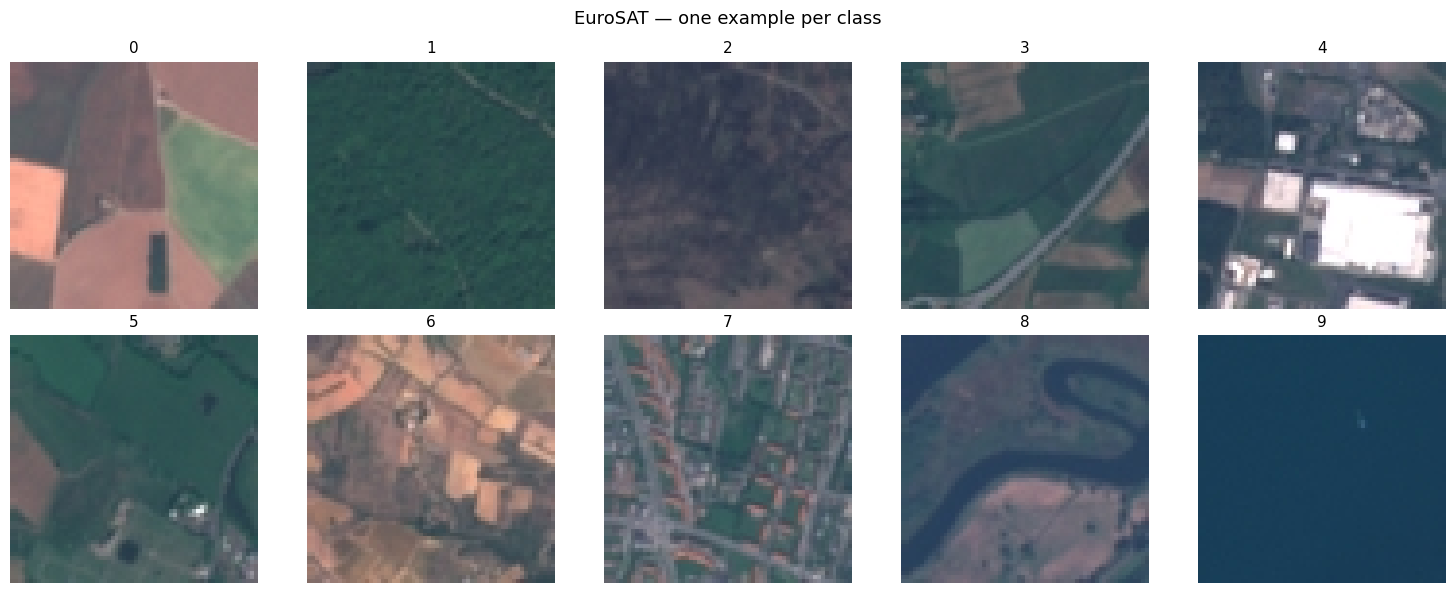

Saved samples to: /kaggle/working/outputs/samples_per_class


In [29]:
import rasterio

SAMPLES_DIR = OUT_DIR / 'samples_per_class'
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

def read_tif_as_rgb(path):
    """Read either an RGB JPG/PNG OR a Sentinel-2 13-band .tif and return a PIL RGB image.
    Sentinel-2 band order in EuroSATallBands: [B01..B08, B8A, B09, B10, B11, B12].
    True-colour RGB uses B04 (Red, idx 3), B03 (Green, idx 2), B02 (Blue, idx 1)."""
    p = str(path)
    if p.lower().endswith(('.tif', '.tiff')):
        with rasterio.open(p) as src:
            arr = src.read()
        rgb = np.stack([arr[3], arr[2], arr[1]], axis=-1).astype(np.float32)
        rmin = rgb.min(axis=(0, 1), keepdims=True)
        rmax = rgb.max(axis=(0, 1), keepdims=True)
        rgb = (rgb - rmin) / (rmax - rmin + 1e-8)
        return Image.fromarray((rgb * 255).clip(0, 255).astype(np.uint8))
    return Image.open(p).convert('RGB')

def export_class_samples(df, n_per_class=8):
    for c in classes:
        sub = df[df[LBL_COL] == c]
        if len(sub) == 0: continue
        sub = sub.sample(min(n_per_class, len(sub)), random_state=SEED)
        imgs = [read_tif_as_rgb(p) for p in sub['abs_path']]
        cols = 4; rows = math.ceil(len(imgs) / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))
        axes = np.array(axes).reshape(-1)
        for ax in axes: ax.axis('off')
        for i, im in enumerate(imgs):
            axes[i].imshow(im); axes[i].set_title(c, fontsize=9)
        fig.tight_layout()
        fig.savefig(SAMPLES_DIR / f'{c}_samples.png', dpi=150)
        plt.close(fig)

export_class_samples(train_df, n_per_class=8)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.reshape(-1)
for i, c in enumerate(classes):
    sample = train_df[train_df[LBL_COL] == c].iloc[0]['abs_path']
    axes[i].imshow(read_tif_as_rgb(sample))
    axes[i].set_title(c, fontsize=11); axes[i].axis('off')
fig.suptitle('EuroSAT — one example per class', fontsize=13)
fig.tight_layout()
fig.savefig(OUT_DIR / 'class_overview.png', dpi=150)
plt.show()
print('Saved samples to:', SAMPLES_DIR)

## 6. Config, transforms, datasets, train + val loaders
Note: we deliberately do **not** create a `test_loader` here. It's built later in section 11.

In [30]:
@dataclass
class CFG:
    image_size: int = 224
    batch_size: int = 128
    num_workers: int = 0   # rasterio/GDAL is not fork-safe — single-process loading is the only safe default on Kaggle
    epochs: int = 12
    lr: float = 3e-4
    weight_decay: float = 1e-4
    label_smoothing: float = 0.05
    grad_clip: float = 1.0
    early_stop_patience: int = 3
    plateau_patience: int = 2
    plateau_factor: float = 0.5
    amp: bool = True

cfg = CFG()
if NUM_GPUS == 0:
    cfg.batch_size = 32; cfg.epochs = 3
elif NUM_GPUS == 1:
    cfg.batch_size = 96
print('CFG:', asdict(cfg))

IM_MEAN = (0.485, 0.456, 0.406)
IM_STD  = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomApply([transforms.ColorJitter(0.2, 0.2, 0.2, 0.05)], p=0.3),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(IM_MEAN, IM_STD),
])
eval_tfms = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(IM_MEAN, IM_STD),
])

def safe_open_rgb(path: str):
    """Open an image as RGB. Handles JPG/PNG via PIL and Sentinel-2 13-band .tif via rasterio.
    Returns None if the file is unreadable."""
    try:
        return read_tif_as_rgb(path)
    except Exception:
        return None

class EuroSATCSVDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        # Try the requested item; if it's unreadable, fall back to subsequent indices.
        n = len(self.df)
        for k in range(n):
            j = (idx + k) % n
            row = self.df.iloc[j]
            img = safe_open_rgb(row['abs_path'])
            if img is None:
                continue
            if self.transform: img = self.transform(img)
            return img, int(row['label_idx']), row['abs_path']
        raise RuntimeError('No readable images in dataset.')

_train_ds = EuroSATCSVDataset(train_df, train_tfms)
_val_ds   = EuroSATCSVDataset(val_df,   eval_tfms)

def make_loaders(batch_size=None):
    bs = batch_size or cfg.batch_size
    g = torch.Generator(); g.manual_seed(SEED)
    nw = cfg.num_workers
    pin = bool(nw and torch.cuda.is_available())
    persistent = bool(nw)
    tl = DataLoader(_train_ds, batch_size=bs, shuffle=True,
                    num_workers=nw, pin_memory=pin, drop_last=True,
                    persistent_workers=persistent,
                    worker_init_fn=seed_worker, generator=g)
    vl = DataLoader(_val_ds, batch_size=bs, shuffle=False,
                    num_workers=nw, pin_memory=pin,
                    persistent_workers=persistent,
                    worker_init_fn=seed_worker)
    return tl, vl

print('train size:', len(_train_ds), '| val size:', len(_val_ds))

CFG: {'image_size': 224, 'batch_size': 128, 'num_workers': 0, 'epochs': 12, 'lr': 0.0003, 'weight_decay': 0.0001, 'label_smoothing': 0.05, 'grad_clip': 1.0, 'early_stop_patience': 3, 'plateau_patience': 2, 'plateau_factor': 0.5, 'amp': True}
train size: 16065 | val size: 2835


## 7. Custom EuroSAT CNN

ResNet-style architecture with squeeze-and-excitation attention, batch norm, dropout, GAP. Around 5.5M parameters. On EuroSAT RGB this typically reaches **96–98% test accuracy** with the augmentation policy above.

In [31]:
class SEBlock(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        h = max(c // r, 4)
        self.fc1 = nn.Linear(c, h)
        self.fc2 = nn.Linear(h, c)
    def forward(self, x):
        s = x.mean(dim=(2, 3))
        s = F.silu(self.fc1(s))
        s = torch.sigmoid(self.fc2(s)).unsqueeze(-1).unsqueeze(-1)
        return x * s

class ResBlock(nn.Module):
    def __init__(self, ic, oc, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(ic, oc, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(oc)
        self.conv2 = nn.Conv2d(oc, oc, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(oc)
        self.se    = SEBlock(oc)
        self.act   = nn.SiLU()
        self.down  = (nn.Identity() if (stride == 1 and ic == oc)
                      else nn.Sequential(
                          nn.Conv2d(ic, oc, 1, stride, bias=False),
                          nn.BatchNorm2d(oc)))
    def forward(self, x):
        idn = self.down(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out) + idn
        return self.act(out)

class CustomEuroSATCNN(nn.Module):
    """Residual + SE-attention CNN tuned for EuroSAT RGB."""
    def __init__(self, n_classes: int):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1, bias=False),
            nn.BatchNorm2d(64), nn.SiLU(),
        )
        self.layer1 = nn.Sequential(ResBlock(64,  64),       ResBlock(64,  64))
        self.layer2 = nn.Sequential(ResBlock(64,  128, 2),   ResBlock(128, 128))
        self.layer3 = nn.Sequential(ResBlock(128, 256, 2),   ResBlock(256, 256))
        self.layer4 = nn.Sequential(ResBlock(256, 512, 2),   ResBlock(512, 512))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(512, n_classes),
        )
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.pool(x)
        return self.head(x)

_demo = CustomEuroSATCNN(num_classes)
print('CustomEuroSATCNN params:', sum(p.numel() for p in _demo.parameters()))
del _demo

CustomEuroSATCNN params: 11263042


## 8. Model factory + training utilities

`train_one_model()` only sees `train_loader` and `val_loader`. The test set is never touched here.

In [32]:
MODEL_SPECS = {
    'custom':       {'name': 'custom_cnn',                       'pretty': 'CustomEuroSATCNN',  'lr': 3e-4, 'bs': 128, 'epochs': 25, 'family': 'cnn'},
}

def build_model(name: str, n_classes: int):
    if name == 'custom_cnn':
        return CustomEuroSATCNN(n_classes)
    return timm.create_model(name, pretrained=True, num_classes=n_classes)

def count_params(m):
    total = sum(p.numel() for p in m.parameters())
    train = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return int(total), int(train)

def topk_predictions(logits, k=2):
    probs = torch.softmax(logits, dim=1)
    top = torch.topk(probs, k=k, dim=1)
    return top.indices, top.values

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    ys, p1, p2, prob1, prob2, paths = [], [], [], [], [], []
    for xb, yb, pb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        idx2, prb2 = topk_predictions(logits, 2)
        ys.append(yb.numpy())
        p1.append(idx2[:, 0].cpu().numpy()); prob1.append(prb2[:, 0].cpu().numpy())
        p2.append(idx2.cpu().numpy());        prob2.append(prb2.cpu().numpy())
        paths.extend(list(pb))
    y_true = np.concatenate(ys);   y_pred = np.concatenate(p1)
    y_top2 = np.concatenate(p2);   c_top1 = np.concatenate(prob1); c_top2 = np.concatenate(prob2)
    return {
        'accuracy':           float(accuracy_score(y_true, y_pred)),
        'f1_macro':           float(f1_score(y_true, y_pred, average='macro')),
        'f1_weighted':        float(f1_score(y_true, y_pred, average='weighted')),
        'balanced_accuracy':  float(balanced_accuracy_score(y_true, y_pred)),
        'top2_accuracy':      float((y_top2 == y_true[:, None]).any(axis=1).mean()),
        'y_true': y_true, 'y_pred': y_pred, 'y_top2': y_top2,
        'conf_top1': c_top1, 'conf_top2': c_top2, 'paths': paths,
    }

def save_checkpoint(path, *, model, optimizer, scheduler, epoch, val_metric, val_loss,
                    model_name, model_key, pretty, cfg_dict):
    # `model.module` branch kept for backwards-compat with older DataParallel checkpoints.
    sd = (model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict())
    torch.save({
        'epoch': int(epoch),
        'model_state_dict':     sd,
        'optimizer_state_dict': optimizer.state_dict() if optimizer is not None else None,
        'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
        'val_accuracy': float(val_metric),
        'val_loss':     float(val_loss),
        'model_name':   model_name,
        'model_key':    model_key,
        'pretty':       pretty,
        'num_classes':  num_classes,
        'class_to_idx': class_to_idx,
        'idx_to_class': idx_to_class,
        'cfg':          cfg_dict,
    }, path)

def _human_int(n):
    for u, v in [('B', 1e9), ('M', 1e6), ('K', 1e3)]:
        if n >= v: return f'{n/v:.2f}{u}'
    return str(n)

def _gpu_mem_gb():
    if not torch.cuda.is_available(): return 0.0
    return sum(torch.cuda.memory_allocated(i) for i in range(torch.cuda.device_count())) / (1024**3)

def _print_banner(spec, model, train_size, val_size, bs, epochs):
    total, trainable = count_params(model)
    bar = '═' * 86
    if NUM_GPUS:
        gpu_str = f'cuda:0 ({torch.cuda.get_device_name(0)})'
        if NUM_GPUS > 1:
            gpu_str += f' — {NUM_GPUS - 1} extra GPU(s) idle (DataParallel disabled for stability)'
    else:
        gpu_str = 'CPU'
    print('\n' + bar)
    print(f'  Training: {spec["pretty"]}  ({spec["name"]})')
    print(bar)
    print(f'   • device       : {DEVICE.type}  ({gpu_str})')
    print(f'   • dataset      : {train_size:,} train  ·  {val_size:,} val  ·  {num_classes} classes')
    print(f'   • parameters   : {_human_int(total)} total  ·  {_human_int(trainable)} trainable')
    print(f'   • batch size   : {bs}')
    print(f'   • optimizer    : AdamW(lr={spec["lr"]:.2e}, weight_decay={cfg.weight_decay})')
    print(f'   • scheduler    : ReduceLROnPlateau(factor={cfg.plateau_factor}, patience={cfg.plateau_patience})')
    print(f'   • loss         : CrossEntropy(label_smoothing={cfg.label_smoothing})')
    print(f'   • mixed prec.  : {bool(cfg.amp and DEVICE.type == "cuda")}')
    print(f'   • max epochs   : {epochs}   (early stop patience = {cfg.early_stop_patience})')
    print(bar + '\n')

def train_one_model(model_key: str = 'custom', override_epochs: int = None):
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        try: torch.cuda.ipc_collect()
        except Exception: pass
        free_b, total_b = torch.cuda.mem_get_info()
        free_gb, total_gb = free_b / 1024**3, total_b / 1024**3
        # ~1 GiB is enough for the model + optimizer + a small smoke-test batch.
        # If we're below that we are almost certainly looking at leaked state from
        # a previous failed run and the user needs to restart the kernel.
        if free_gb < 1.0:
            raise RuntimeError(
                f'Only {free_gb:.2f} GiB free on {torch.cuda.get_device_name(0)} '
                f'({total_gb:.2f} GiB total). This is almost always leaked memory '
                f'from a previous failed training attempt that this kernel still '
                f'holds references to. Please **Restart Kernel & Run All** in '
                f'Jupyter (or run `hard_cuda_purge()` immediately before this cell) '
                f'and try again.'
            )
        print(f'  GPU memory before training : {free_gb:.2f} / {total_gb:.2f} GiB free')
    spec   = MODEL_SPECS[model_key]
    pretty = spec['pretty']

    # We train on a single GPU only — nn.DataParallel + AMP + custom SE blocks
    # has historically triggered cudaErrorIllegalAddress on Kaggle's dual T4.
    # On a 16 GB T4 the SE-attention activations at 224×224 dominate memory, so
    # 64 is the realistic ceiling for this 5.5M-param residual+SE net under AMP.
    # The OOM fallback below will halve `bs` again automatically if needed.
    bs = spec['bs']
    if NUM_GPUS == 0:
        bs = min(bs, 32)
    else:
        bs = min(bs, 64)
    bs_min = 8

    def _build_state(batch_size):
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        tl, vl = make_loaders(batch_size=batch_size)
        m = build_model(spec['name'], num_classes).to(DEVICE)
        opt = torch.optim.AdamW(m.parameters(), lr=spec['lr'], weight_decay=cfg.weight_decay)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode='max', factor=cfg.plateau_factor, patience=cfg.plateau_patience
        )
        sc = torch.amp.GradScaler('cuda', enabled=(cfg.amp and DEVICE.type == 'cuda'))
        return tl, vl, m, opt, sch, sc

    train_loader, val_loader, model, optimizer, scheduler, scaler = _build_state(bs)

    epochs    = override_epochs or spec.get('epochs', cfg.epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)

    _print_banner(spec, model, len(train_loader.dataset), len(val_loader.dataset), bs, epochs)

    # ---- smoke test: one fwd+bwd on a tiny batch to surface CUDA/label errors early ----
    try:
        sb_xb, sb_yb, _ = next(iter(train_loader))
        sb_xb = sb_xb[:8].to(DEVICE); sb_yb = sb_yb[:8].to(DEVICE)
        if not (0 <= int(sb_yb.min().item()) and int(sb_yb.max().item()) < num_classes):
            raise RuntimeError(f'label range bad: min={int(sb_yb.min())} max={int(sb_yb.max())} (num_classes={num_classes})')
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=(cfg.amp and DEVICE.type == 'cuda')):
            out = model(sb_xb); l = criterion(out, sb_yb)
        l.backward()
        optimizer.zero_grad(set_to_none=True)  # clear smoke-test grads
        if torch.isnan(out).any() or torch.isinf(out).any():
            raise RuntimeError('NaN/Inf in forward output')
        print('  smoke test passed (1 fwd+bwd on bs=8 ✔)\n')
        del sb_xb, sb_yb, out, l
        torch.cuda.empty_cache()
    except Exception as e:
        raise RuntimeError(f'smoke test failed before training: {e}')

    best_acc, best_ep, no_imp, history, t_total = -1.0, -1, 0, [], time.time()
    best_path    = CKPT_DIR / f'best_{model_key}.pth'
    last_path    = CKPT_DIR / f'last_{model_key}.pth'
    weights_path = CKPT_DIR / f'{model_key}_weights.pth'
    cfg_dict = asdict(cfg) | {'model_lr': spec['lr'], 'model_bs': bs, 'planned_epochs': epochs}

    ep = 0
    while ep < epochs:
        ep += 1
        ep_t0 = time.time()
        model.train()
        loss_sum, correct, n_seen = 0.0, 0, 0
        bar = tqdm(train_loader,
                   desc=f'  ep {ep:>2}/{epochs} ▸ train',
                   ncols=120, leave=False, dynamic_ncols=False)
        oom_retry = False
        for xb, yb, _ in bar:
            try:
                xb = xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True)
                # Defensive label-range check — a stale/bad label index is the most common
                # cause of an out-of-bounds index inside CrossEntropy that surfaces only
                # as an "illegal memory access" during the next backward pass.
                if (yb.min().item() < 0) or (yb.max().item() >= num_classes):
                    raise RuntimeError(
                        f'label out of range: min={int(yb.min())} max={int(yb.max())} '
                        f'(num_classes={num_classes})'
                    )
                optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast('cuda', enabled=(cfg.amp and DEVICE.type == 'cuda')):
                    logits = model(xb); loss = criterion(logits, yb)
                scaler.scale(loss).backward()
                if cfg.grad_clip:
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(optimizer); scaler.update()
                with torch.no_grad():
                    bs_  = yb.size(0)
                    loss_sum += float(loss.item()) * bs_
                    correct  += int((logits.argmax(1) == yb).sum().item())
                    n_seen   += bs_
                bar.set_postfix(loss=f'{loss_sum/n_seen:.4f}',
                                acc=f'{100*correct/n_seen:5.2f}%',
                                lr=f"{optimizer.param_groups[0]['lr']:.1e}",
                                gpu=f'{_gpu_mem_gb():.1f}G')
                del xb, yb, logits, loss
            except torch.cuda.OutOfMemoryError as e:
                # Graceful auto-fallback: free everything, halve batch size, restart this epoch.
                bar.close()
                new_bs = max(bs // 2, bs_min)
                if new_bs >= bs:
                    raise
                print(f'\n  ⚠ CUDA OOM at bs={bs} ({e}). Rebuilding with bs={new_bs} and retrying epoch {ep}.')
                try:
                    optimizer.zero_grad(set_to_none=True)
                except Exception:
                    pass
                del optimizer, scheduler, scaler, model, train_loader, val_loader
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache(); torch.cuda.synchronize()
                bs = new_bs
                train_loader, val_loader, model, optimizer, scheduler, scaler = _build_state(bs)
                model.train()
                ep -= 1   # redo this epoch from the start with the new bs
                oom_retry = True
                break
        if oom_retry:
            continue
        bar.close()
        train_loss = loss_sum / max(1, n_seen)
        train_acc  = correct  / max(1, n_seen)

        # ---- validation ----
        model.eval()
        v_loss_sum, v_correct, v_n = 0.0, 0, 0
        ys, p1, p2 = [], [], []
        vbar = tqdm(val_loader,
                    desc=f'  ep {ep:>2}/{epochs} ▸   val',
                    ncols=120, leave=False, dynamic_ncols=False)
        with torch.no_grad():
            for xb, yb, _ in vbar:
                xb = xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True)
                logits = model(xb); l = criterion(logits, yb)
                bs_  = yb.size(0)
                v_loss_sum += float(l.item()) * bs_
                v_correct  += int((logits.argmax(1) == yb).sum().item())
                v_n        += bs_
                idx2, _ = topk_predictions(logits, 2)
                ys.append(yb.cpu().numpy())
                p1.append(idx2[:, 0].cpu().numpy())
                p2.append(idx2.cpu().numpy())
                vbar.set_postfix(loss=f'{v_loss_sum/v_n:.4f}',
                                 acc=f'{100*v_correct/v_n:5.2f}%')
        vbar.close()
        val_loss = v_loss_sum / max(1, v_n)
        y_true   = np.concatenate(ys); y_pred = np.concatenate(p1); y_top2 = np.concatenate(p2)
        val_acc  = float(accuracy_score(y_true, y_pred))
        val_f1m  = float(f1_score(y_true, y_pred, average='macro'))
        val_f1w  = float(f1_score(y_true, y_pred, average='weighted'))
        val_bal  = float(balanced_accuracy_score(y_true, y_pred))
        val_top2 = float((y_top2 == y_true[:, None]).any(axis=1).mean())
        scheduler.step(val_acc)

        improved = val_acc > best_acc
        if improved:
            tag = '★ new best — saved'
        elif best_ep > 0:
            tag = f'(best ep{best_ep:>2}: {best_acc*100:.2f}%, {no_imp+1}/{cfg.early_stop_patience} no-imp)'
        else:
            tag = ''
        dt = time.time() - ep_t0
        print(
            f'  ep {ep:>2}/{epochs}  '
            f'train  loss {train_loss:.4f}  acc {train_acc*100:5.2f}%   '
            f'│  val  loss {val_loss:.4f}  acc {val_acc*100:5.2f}%  top2 {val_top2*100:5.2f}%  '
            f'f1 {val_f1m:.4f}   '
            f'│  lr {optimizer.param_groups[0]["lr"]:.1e}  '
            f'⏱ {dt:5.1f}s  {tag}'
        )

        history.append({
            'epoch': ep, 'train_loss': train_loss, 'train_acc': train_acc,
            'val_loss': val_loss, 'val_accuracy': val_acc, 'val_top2_accuracy': val_top2,
            'val_f1_macro': val_f1m, 'val_f1_weighted': val_f1w,
            'val_balanced_accuracy': val_bal,
            'lr': optimizer.param_groups[0]['lr'], 'epoch_seconds': dt,
        })

        save_checkpoint(last_path, model=model, optimizer=optimizer, scheduler=scheduler,
                        epoch=ep, val_metric=val_acc, val_loss=val_loss,
                        model_name=spec['name'], model_key=model_key, pretty=pretty,
                        cfg_dict=cfg_dict)
        if improved:
            best_acc, best_ep, no_imp = val_acc, ep, 0
            save_checkpoint(best_path, model=model, optimizer=optimizer, scheduler=scheduler,
                            epoch=ep, val_metric=val_acc, val_loss=val_loss,
                            model_name=spec['name'], model_key=model_key, pretty=pretty,
                            cfg_dict=cfg_dict)
            sd = (model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict())
            torch.save(sd, weights_path)
        else:
            no_imp += 1
        if no_imp >= cfg.early_stop_patience:
            print(f'\n  early stop @ epoch {ep} — no val improvement for {cfg.early_stop_patience} epochs.')
            break

        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    pd.DataFrame(history).to_csv(OUT_DIR / f'history_{model_key}.csv', index=False)
    elapsed = time.time() - t_total
    line = '─' * 86
    print('\n' + line)
    print(f'  ✔ training done · {pretty}')
    print(f'    best val accuracy : {best_acc*100:.2f}%  (epoch {best_ep})')
    print(f'    epochs trained    : {len(history)} of {epochs} planned')
    print(f'    total time        : {elapsed/60:.1f} min')
    print(f'    best ckpt   → {best_path}')
    print(f'    last ckpt   → {last_path}')
    print(f'    weights     → {weights_path}')
    print(line)

    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {'best': best_path, 'last': last_path, 'weights': weights_path, 'val_accuracy': best_acc}

def load_model_from_checkpoint(ckpt_path):
    """Load a clean (non-DataParallel) model from a saved checkpoint for evaluation / XAI."""
    ck = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    m = build_model(ck['model_name'], ck['num_classes'])
    m.load_state_dict(ck['model_state_dict'])
    m.to(DEVICE).eval()
    return m, ck

checkpoints = {}
if (OUT_DIR / 'checkpoints.json').exists():
    checkpoints = json.loads((OUT_DIR / 'checkpoints.json').read_text())
    print('Loaded existing checkpoints.json:', list(checkpoints.keys()))

def remember_checkpoint(model_key, info):
    checkpoints[model_key] = {k: str(v) if isinstance(v, Path) else v for k, v in info.items()}
    (OUT_DIR / 'checkpoints.json').write_text(json.dumps(checkpoints, indent=2))

---
## 9. Train CustomEuroSATCNN
The single model in this notebook. Re-run this cell to retrain; the next sections evaluate and explain whatever checkpoint it produced.

### CustomEuroSATCNN

In [33]:
def hard_cuda_purge(verbose: bool = True):
    """Free every leaked GPU tensor / module sitting in this kernel's globals.

    Re-running training cells after a previous OOM/illegal-memory-access leaves
    behind references to old models, optimizers, and AMP scalers, so the CUDA
    caching allocator never returns the memory. This walks `globals()`, deletes
    anything CUDA-resident, and forces the allocator to release its cache.
    """
    import gc as _gc
    purged = 0
    PROTECT = {'In', 'Out', 'exit', 'quit', 'get_ipython',
               'hard_cuda_purge', 'train_one_model',
               'load_model_from_checkpoint', 'build_model'}
    for name in list(globals()):
        if name.startswith('_') or name in PROTECT: continue
        obj = globals().get(name)
        try:
            should_purge = False
            if isinstance(obj, torch.Tensor) and obj.is_cuda:
                should_purge = True
            elif isinstance(obj, torch.nn.Module):
                try:
                    if any(p.is_cuda for p in obj.parameters(recurse=True)):
                        should_purge = True
                except Exception:
                    pass
            elif isinstance(obj, (torch.optim.Optimizer, torch.amp.GradScaler)):
                should_purge = True
            if should_purge:
                try: del globals()[name]; purged += 1
                except Exception:
                    globals()[name] = None; purged += 1
        except Exception:
            pass
    for _ in range(3):
        _gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        try: torch.cuda.ipc_collect()
        except Exception: pass
        free, total = torch.cuda.mem_get_info()
        if verbose:
            print(f'  hard_cuda_purge: cleared {purged} stale CUDA refs · '
                  f'GPU free {free/1024**3:.2f} / {total/1024**3:.2f} GiB')
    elif verbose:
        print(f'  hard_cuda_purge: cleared {purged} stale refs (CPU only).')

hard_cuda_purge()
info = train_one_model('custom')
remember_checkpoint('custom', info)
print('Saved Custom CNN ->', info)

  hard_cuda_purge: cleared 0 stale CUDA refs · GPU free 14.29 / 14.56 GiB
  GPU memory before training : 14.29 / 14.56 GiB free

══════════════════════════════════════════════════════════════════════════════════════
  Training: CustomEuroSATCNN  (custom_cnn)
══════════════════════════════════════════════════════════════════════════════════════
   • device       : cuda  (cuda:0 (Tesla T4) — 1 extra GPU(s) idle (DataParallel disabled for stability))
   • dataset      : 16,065 train  ·  2,835 val  ·  10 classes
   • parameters   : 11.26M total  ·  11.26M trainable
   • batch size   : 64
   • optimizer    : AdamW(lr=3.00e-04, weight_decay=0.0001)
   • scheduler    : ReduceLROnPlateau(factor=0.5, patience=2)
   • loss         : CrossEntropy(label_smoothing=0.05)
   • mixed prec.  : True
   • max epochs   : 25   (early stop patience = 3)
══════════════════════════════════════════════════════════════════════════════════════

  smoke test passed (1 fwd+bwd on bs=8 ✔)



  ep  1/25  train  loss 1.2788  acc 60.08%   │  val  loss 1.0616  acc 67.48%  top2 85.29%  f1 0.6348   │  lr 3.0e-04  ⏱ 566.3s  ★ new best — saved


  ep  2/25  train  loss 0.8930  acc 75.87%   │  val  loss 0.6785  acc 85.19%  top2 95.27%  f1 0.8451   │  lr 3.0e-04  ⏱ 429.6s  ★ new best — saved


  ep  3/25  train  loss 0.7213  acc 83.40%   │  val  loss 0.7281  acc 83.63%  top2 94.67%  f1 0.8274   │  lr 3.0e-04  ⏱ 428.3s  (best ep 2: 85.19%, 1/3 no-imp)


  ep  4/25  train  loss 0.6484  acc 86.39%   │  val  loss 0.5674  acc 89.91%  top2 96.83%  f1 0.8965   │  lr 3.0e-04  ⏱ 431.7s  ★ new best — saved


...

  ep 14/25  train  loss 0.4451  acc 94.07%   │  val  loss 0.4049  acc 95.80%  top2 99.22%  f1 0.9569   │  lr 3.0e-04  ⏱ 424.6s  ★ new best — saved


  ep 15/25  train  loss 0.4333  acc 94.50%   │  val  loss 0.3984  acc 96.44%  top2 99.33%  f1 0.9630   │  lr 3.0e-04  ⏱ 429.5s  ★ new best — saved


  ep 16/25  train  loss 0.4335  acc 94.53%   │  val  loss 0.7522  acc 84.06%  top2 89.98%  f1 0.8237   │  lr 3.0e-04  ⏱ 428.6s  (best ep15: 96.44%, 1/3 no-imp)


  ep 17/25  train  loss 0.4283  acc 94.65%   │  val  loss 0.4277  acc 94.78%  top2 99.12%  f1 0.9457   │  lr 3.0e-04  ⏱ 427.0s  (best ep15: 96.44%, 2/3 no-imp)


  ep 18/25  train  loss 0.4176  acc 95.15%   │  val  loss 0.4007  acc 96.30%  top2 99.01%  f1 0.9614   │  lr 1.5e-04  ⏱ 424.7s  (best ep15: 96.44%, 3/3 no-imp)

  early stop @ epoch 18 — no val improvement for 3 epochs.

──────────────────────────────────────────────────────────────────────────────────────
  ✔ training done · CustomEuroSATCNN
    best val accuracy : 96.44%  (epoch 15)
    epochs trained    : 18 of 25 planned
    total time        : 130.7 min
    best ckpt   → /kaggle/working/outputs/checkpoints/best_custom.pth
    last ckpt   → /kaggle/working/outputs/checkpoints/last_custom.pth
    weights     → /kaggle/working/outputs/checkpoints/custom_weights.pth
──────────────────────────────────────────────────────────────────────────────────────
Saved Custom CNN -> {'best': PosixPath('/kaggle/working/outputs/checkpoints/best_custom.pth'), 'last': PosixPath('/kaggle/working/outputs/checkpoints/last_custom.pth'), 'weights': PosixPath('/kaggle/working/outputs/checkpoints/custom_wei

## 10. Validation evaluation
Evaluate the **best checkpoint** on the validation set (no test-set leakage).

In [34]:
_, val_loader = make_loaders()
rows = []
for k, info in checkpoints.items():
    bp = Path(info['best'])
    if not bp.exists():
        print(f'Skipping {k}: missing {bp}'); continue
    model, ck = load_model_from_checkpoint(bp)
    m = evaluate(model, val_loader)
    total, trainp = count_params(model)
    rows.append({
        'model_key': k, 'pretty': ck['pretty'], 'model_name': ck['model_name'],
        'val_accuracy': m['accuracy'], 'val_top2_accuracy': m['top2_accuracy'],
        'val_f1_macro': m['f1_macro'], 'val_f1_weighted': m['f1_weighted'],
        'val_balanced_accuracy': m['balanced_accuracy'],
        'total_params': total, 'trainable_params': trainp,
        'best_ckpt': str(bp), 'last_ckpt': info.get('last', ''),
    })
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()

val_cmp = pd.DataFrame(rows).sort_values('val_accuracy', ascending=False).reset_index(drop=True)
val_cmp.to_csv(OUT_DIR / 'val_metrics.csv', index=False)
bar = '═' * 86
print(bar + '\n  VALIDATION METRICS  (best checkpoint)\n' + bar)
for _, r in val_cmp.iterrows():
    print(f"   {r['pretty']:<22} accuracy={r['val_accuracy']*100:6.2f}%  "
          f"top2={r['val_top2_accuracy']*100:6.2f}%  f1_macro={r['val_f1_macro']:.4f}  "
          f"balanced={r['val_balanced_accuracy']:.4f}")
print(bar)
val_cmp

══════════════════════════════════════════════════════════════════════════════════════
  VALIDATION METRICS  (best checkpoint)
══════════════════════════════════════════════════════════════════════════════════════
   CustomEuroSATCNN       accuracy= 96.44%  top2= 99.33%  f1_macro=0.9630  balanced=0.9631
══════════════════════════════════════════════════════════════════════════════════════


,model_key,pretty,model_name,val_accuracy,val_top2_accuracy,val_f1_macro,val_f1_weighted,val_balanced_accuracy,total_params,trainable_params,best_ckpt,last_ckpt
0,custom,CustomEuroSATCNN,custom_cnn,0.964374,0.993298,0.962951,0.964285,0.96305,11263042,11263042,/kaggle/working/outputs/checkpoints/best_custo...,/kaggle/working/outputs/checkpoints/last_custo...


---
## 11. Final locked test phase (test.csv used **once**)
Loads the best checkpoint, evaluates on `test_df`, and saves the classification report, confusion matrix, and a predictions CSV with top-1 / top-2 land-uses and confidence scores.

In [35]:
_test_ds = EuroSATCSVDataset(test_df, eval_tfms)
test_loader = DataLoader(_test_ds, batch_size=cfg.batch_size, shuffle=False,
                         num_workers=cfg.num_workers,
                         pin_memory=bool(cfg.num_workers and torch.cuda.is_available()),
                         worker_init_fn=seed_worker)
print('Locked test set size:', len(_test_ds))

def save_confusion_matrix(cm, title, save_path):
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks(range(num_classes)); ax.set_yticks(range(num_classes))
    ax.set_xticklabels([idx_to_class[i] for i in range(num_classes)], rotation=45, ha='right')
    ax.set_yticklabels([idx_to_class[i] for i in range(num_classes)])
    mx = cm.max() if cm.max() else 1
    for i in range(num_classes):
        for j in range(num_classes):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > mx/2 else 'black', fontsize=8)
    fig.colorbar(im, ax=ax)
    fig.tight_layout(); fig.savefig(save_path, dpi=150); plt.close(fig)

test_rows = []
for k, info in checkpoints.items():
    bp = Path(info['best'])
    if not bp.exists():
        print(f'Skipping {k}: missing {bp}'); continue
    model, ck = load_model_from_checkpoint(bp)
    m = evaluate(model, test_loader)
    total, trainp = count_params(model)

    metrics_dir = TEST_DIR / k
    metrics_dir.mkdir(parents=True, exist_ok=True)

    metrics = {
        'model_key': k, 'pretty': ck['pretty'], 'model_name': ck['model_name'],
        'test_accuracy': m['accuracy'], 'test_top2_accuracy': m['top2_accuracy'],
        'test_f1_macro': m['f1_macro'], 'test_f1_weighted': m['f1_weighted'],
        'test_balanced_accuracy': m['balanced_accuracy'],
        'total_params': total, 'trainable_params': trainp,
        'best_ckpt': str(bp),
    }
    (metrics_dir / 'metrics.json').write_text(json.dumps(metrics, indent=2))

    rep = classification_report(m['y_true'], m['y_pred'],
                                target_names=[idx_to_class[i] for i in range(num_classes)])
    (metrics_dir / 'classification_report.txt').write_text(rep)

    cm = confusion_matrix(m['y_true'], m['y_pred'])
    np.save(metrics_dir / 'confusion_matrix.npy', cm)
    save_confusion_matrix(cm, f"Confusion — {ck['pretty']} (test)", metrics_dir / 'confusion_matrix.png')

    pred_df = pd.DataFrame({
        'abs_path':         m['paths'],
        'true_idx':         m['y_true'],
        'true_label':       [idx_to_class[i] for i in m['y_true']],
        'pred_top1_idx':    m['y_pred'],
        'pred_top1_label':  [idx_to_class[i] for i in m['y_pred']],
        'pred_top1_prob':   m['conf_top1'],
        'pred_top2_idx':    [list(map(int, x)) for x in m['y_top2']],
        'pred_top2_label':  [[idx_to_class[int(i)] for i in x] for x in m['y_top2']],
        'pred_top2_probs':  [list(map(float, x)) for x in m['conf_top2']],
        'top1_correct':     (m['y_true'] == m['y_pred']),
        'top2_correct':     (m['y_top2'] == m['y_true'][:, None]).any(axis=1),
    })
    pred_df.to_csv(PRED_DIR / f'predictions_{k}.csv', index=False)

    test_rows.append(metrics)
    print(f"  {ck['pretty']:<22}  test_acc={m['accuracy']:.4f}  top2={m['top2_accuracy']:.4f}  f1m={m['f1_macro']:.4f}")
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()

test_cmp = pd.DataFrame(test_rows).sort_values('test_accuracy', ascending=False).reset_index(drop=True)
test_cmp.to_csv(OUT_DIR / 'test_metrics.csv', index=False)
bar = '═' * 86
print('\n' + bar + '\n  FINAL LOCKED TEST METRICS\n' + bar)
for _, r in test_cmp.iterrows():
    print(f"   {r['pretty']:<22} accuracy={r['test_accuracy']*100:6.2f}%  "
          f"top2={r['test_top2_accuracy']*100:6.2f}%  f1_macro={r['test_f1_macro']:.4f}  "
          f"balanced={r['test_balanced_accuracy']:.4f}")
print(bar)
test_cmp

Locked test set size: 2700
  CustomEuroSATCNN        test_acc=0.9659  top2=0.9948  f1m=0.9639

══════════════════════════════════════════════════════════════════════════════════════
  FINAL LOCKED TEST METRICS
══════════════════════════════════════════════════════════════════════════════════════
   CustomEuroSATCNN       accuracy= 96.59%  top2= 99.48%  f1_macro=0.9639  balanced=0.9640
══════════════════════════════════════════════════════════════════════════════════════


,model_key,pretty,model_name,test_accuracy,test_top2_accuracy,test_f1_macro,test_f1_weighted,test_balanced_accuracy,total_params,trainable_params,best_ckpt
0,custom,CustomEuroSATCNN,custom_cnn,0.965926,0.994815,0.963852,0.96586,0.963967,11263042,11263042,/kaggle/working/outputs/checkpoints/best_custo...


## 12. XAI — Grad-CAM (CNN models only by default)

Grad-CAM works cleanly on CNNs (ResNet / DenseNet / Custom). For ViT and Swin, layer hooks and reshape transforms are sensitive to `timm` internals, so transformer Grad-CAM is **off by default**. Set `INCLUDE_TRANSFORMER_GRADCAM = True` to attempt it; failures are caught and logged so the rest of the pipeline keeps running.

Running Grad-CAM for: ['custom']
  Grad-CAM saved -> /kaggle/working/outputs/xai/gradcam/custom


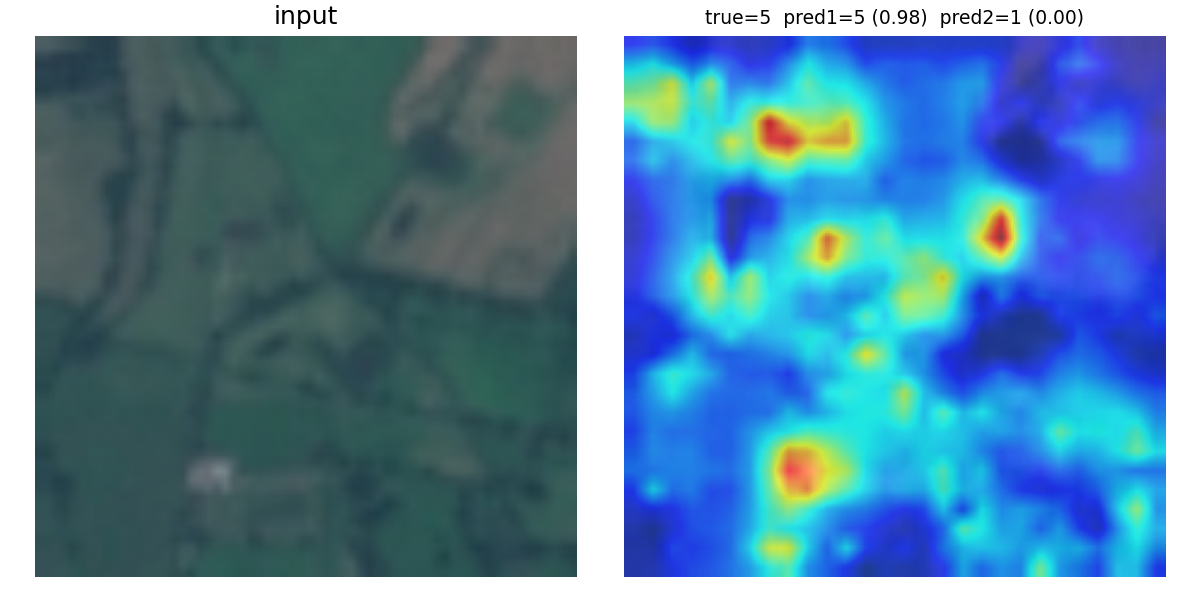

In [36]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

INCLUDE_TRANSFORMER_GRADCAM = False

def denorm(t):
    mean = torch.tensor(IM_MEAN, device=t.device).view(3, 1, 1)
    std  = torch.tensor(IM_STD,  device=t.device).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

def vit_reshape(tensor, h=14, w=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), h, w, tensor.size(2))
    return result.transpose(2, 3).transpose(1, 2)

def swin_reshape(tensor, h=7, w=7):
    if tensor.ndim == 4:
        return tensor.permute(0, 3, 1, 2)
    return tensor.reshape(tensor.size(0), h, w, tensor.size(2)).permute(0, 3, 1, 2)

def get_target_layers_and_reshape(model, model_name: str):
    """Best-effort. Returns (layers, reshape_fn, layer_name, family)."""
    n = model_name.lower()
    try:
        if n == 'custom_cnn':
            return [model.layer4[-1]], None, 'layer4[-1]', 'cnn'
        if 'resnet' in n:
            return [model.layer4[-1]], None, 'layer4[-1]', 'cnn'
        if 'densenet' in n:
            return [model.features.denseblock4], None, 'features.denseblock4', 'cnn'
        if 'vit' in n:
            return [model.blocks[-1].norm1], vit_reshape, 'blocks[-1].norm1', 'transformer'
        if 'swin' in n:
            return [model.layers[-1].blocks[-1].norm1], swin_reshape, 'layers[-1].blocks[-1].norm1', 'transformer'
    except Exception:
        pass
    convs = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    return [convs[-1]], None, 'last_conv_fallback', 'cnn'

def gradcam_explain(model, model_name, image_paths, out_dir, true_labels=None):
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    model.eval()
    paths = list(image_paths)
    pil = [read_tif_as_rgb(p) for p in paths]
    xb = torch.stack([eval_tfms(im) for im in pil]).to(DEVICE)
    with torch.no_grad():
        logits = model(xb)
        idx2, prob2 = topk_predictions(logits, 2)

    targets, reshape, layer_name, family = get_target_layers_and_reshape(model, model_name)
    cam = GradCAM(model=model, target_layers=targets, reshape_transform=reshape)

    raw, saved = [], []
    for i, p in enumerate(paths):
        t = xb[i:i+1]
        pred_idx = int(idx2[i, 0].item())
        gc = cam(input_tensor=t, targets=[ClassifierOutputTarget(pred_idx)])[0]
        raw.append(gc.astype(np.float32))
        rgb = denorm(t[0]).permute(1, 2, 0).detach().cpu().numpy().astype(np.float32)
        vis = show_cam_on_image(rgb, gc, use_rgb=True)
        true_str = idx_to_class[true_labels[i]] if true_labels is not None else '?'
        title = (f"true={true_str}  pred1={idx_to_class[pred_idx]} ({float(prob2[i,0]):.2f})  "
                 f"pred2={idx_to_class[int(idx2[i,1].item())]} ({float(prob2[i,1]):.2f})")
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(rgb); axes[0].set_title('input'); axes[0].axis('off')
        axes[1].imshow(vis); axes[1].set_title(title, fontsize=9); axes[1].axis('off')
        fig.tight_layout()
        out_path = out_dir / f'gradcam_{i:02d}_{Path(p).stem}.png'
        fig.savefig(out_path, dpi=150); plt.close(fig)
        saved.append(str(out_path))
    np.savez_compressed(
        out_dir / 'gradcam_heatmaps.npz',
        heatmaps=np.stack(raw) if raw else np.zeros((0,)),
        image_paths=np.array(paths),
        target_layer=layer_name, model_name=model_name, family=family,
    )
    return saved, layer_name, family

# pick a fixed XAI sample set (12 images) from the locked test set, reproducible
xai_sample = test_df.sample(min(12, len(test_df)), random_state=SEED).reset_index(drop=True)
xai_paths  = xai_sample['abs_path'].tolist()
xai_true   = xai_sample['label_idx'].tolist()
xai_sample[['abs_path', LBL_COL]].to_csv(OUT_DIR / 'xai_sample_set.csv', index=False)

# select XAI candidates: top-3 from test_cmp, but filter to CNN family unless flag is set
TOP_KEYS_ALL = test_cmp['model_key'].tolist()
GRADCAM_KEYS = []
for k in TOP_KEYS_ALL:
    fam = MODEL_SPECS[k]['family']
    if fam == 'cnn' or INCLUDE_TRANSFORMER_GRADCAM:
        GRADCAM_KEYS.append(k)
GRADCAM_KEYS = GRADCAM_KEYS[:4]
print('Running Grad-CAM for:', GRADCAM_KEYS)

for mk in GRADCAM_KEYS:
    bp = Path(checkpoints[mk]['best'])
    try:
        model, ck = load_model_from_checkpoint(bp)
        out_dir = GRAD_DIR / mk
        gradcam_explain(model, ck['model_name'], xai_paths, out_dir, true_labels=xai_true)
        print(f'  Grad-CAM saved -> {out_dir}')
    except Exception as e:
        print(f'  Grad-CAM FAILED for {mk}: {e}')
        traceback.print_exc()
    finally:
        if 'model' in dir() and model is not None: del model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

preview = sorted((GRAD_DIR / GRADCAM_KEYS[0]).glob('*.png')) if GRADCAM_KEYS else []
if preview:
    display(Image.open(preview[0]))

## 13. XAI — LIME
LIME is model-agnostic, so it's safe to run on transformers too. We still wrap it in `try/except` so a failure on one image doesn't abort the rest.

Running LIME for: ['custom']


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  LIME saved -> /kaggle/working/outputs/xai/lime/custom


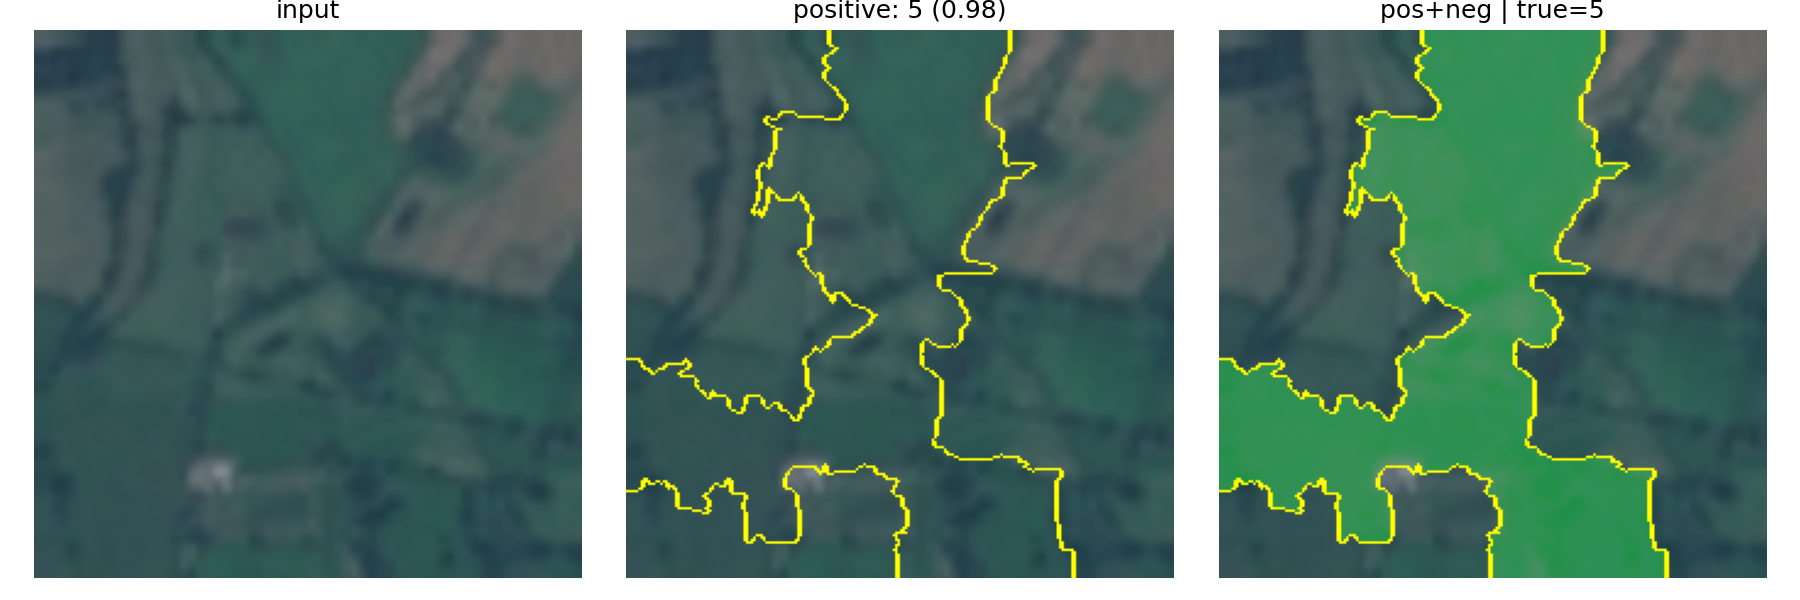

In [37]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

LIME_KEYS = TOP_KEYS_ALL[:3]
print('Running LIME for:', LIME_KEYS)

def lime_predict_fn(model):
    @torch.no_grad()
    def fn(images):
        batch = []
        for im in images:
            if isinstance(im, np.ndarray):
                if im.dtype != np.uint8:
                    im = (im * 255).astype(np.uint8)
                im = Image.fromarray(im)
            batch.append(eval_tfms(im.convert('RGB')))
        xb = torch.stack(batch).to(DEVICE)
        return torch.softmax(model(xb), dim=1).cpu().numpy()
    return fn

def lime_explain(model, model_key, image_paths, out_dir, max_images=8, true_labels=None):
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    model.eval()
    explainer = lime_image.LimeImageExplainer(random_state=SEED)
    pred_fn = lime_predict_fn(model)
    saved = []
    for i, p in enumerate(list(image_paths)[:max_images]):
        try:
            pil = read_tif_as_rgb(p).resize((cfg.image_size, cfg.image_size))
            arr = np.array(pil)
            probs = pred_fn([arr])[0]
            pred_idx = int(np.argmax(probs))
            exp = explainer.explain_instance(arr, pred_fn, top_labels=2,
                                             hide_color=0, num_samples=1000)
            with open(out_dir / f'lime_{i:02d}_{Path(p).stem}.pkl', 'wb') as f:
                pickle.dump({
                    'image_path': str(p),
                    'pred_idx': pred_idx, 'pred_label': idx_to_class[pred_idx],
                    'probs': probs, 'segments': exp.segments,
                    'top_labels': exp.top_labels, 'local_exp': dict(exp.local_exp),
                    'intercept': dict(exp.intercept), 'score': exp.score,
                    'local_pred': exp.local_pred,
                }, f)
            tp, mp = exp.get_image_and_mask(label=pred_idx, positive_only=True,
                                            num_features=10, hide_rest=False)
            tb, mb = exp.get_image_and_mask(label=pred_idx, positive_only=False,
                                            num_features=10, hide_rest=False)
            true_str = idx_to_class[true_labels[i]] if true_labels is not None else '?'
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(arr);                                 axes[0].set_title('input');                                                                       axes[0].axis('off')
            axes[1].imshow(mark_boundaries(tp / 255.0, mp));     axes[1].set_title(f'positive: {idx_to_class[pred_idx]} ({probs[pred_idx]:.2f})');                  axes[1].axis('off')
            axes[2].imshow(mark_boundaries(tb / 255.0, mb));     axes[2].set_title(f'pos+neg | true={true_str}');                                                  axes[2].axis('off')
            fig.tight_layout()
            out_path = out_dir / f'lime_{i:02d}_{Path(p).stem}.png'
            fig.savefig(out_path, dpi=150); plt.close(fig)
            saved.append(str(out_path))
        except Exception as e:
            print(f'  LIME failed for {p}: {e}')
    return saved

for mk in LIME_KEYS:
    bp = Path(checkpoints[mk]['best'])
    model = None
    try:
        model, ck = load_model_from_checkpoint(bp)
        out_dir = LIME_DIR / mk
        lime_explain(model, mk, xai_paths, out_dir,
                     max_images=min(8, len(xai_paths)), true_labels=xai_true)
        print(f'  LIME saved -> {out_dir}')
    except Exception as e:
        print(f'  LIME FAILED for {mk}: {e}')
        traceback.print_exc()
    finally:
        if model is not None: del model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

preview = sorted((LIME_DIR / LIME_KEYS[0]).glob('*.png')) if LIME_KEYS else []
if preview:
    display(Image.open(preview[0]))

## 14. Save XAI bundle (`.pth`)
Self-contained packages with `state_dict` + everything needed to re-explain new images later (Grad-CAM target layer name, reshape kind, normalization, image size, sample paths).

In [38]:
def reshape_kind_for(model_name: str):
    n = model_name.lower()
    if 'vit' in n:  return 'vit'
    if 'swin' in n: return 'swin'
    return None

for mk in (set(GRADCAM_KEYS) | set(LIME_KEYS)):
    bp = Path(checkpoints[mk]['best'])
    if not bp.exists(): continue
    try:
        model, ck = load_model_from_checkpoint(bp)
        _, _, target_name, family = get_target_layers_and_reshape(model, ck['model_name'])
        bundle_path = XB_DIR / f'xai_bundle_{mk}.pth'
        torch.save({
            'model_key': mk, 'model_name': ck['model_name'], 'pretty': ck['pretty'],
            'state_dict': ck['model_state_dict'], 'num_classes': num_classes,
            'class_to_idx': class_to_idx, 'idx_to_class': idx_to_class,
            'image_size': cfg.image_size, 'norm_mean': IM_MEAN, 'norm_std': IM_STD,
            'target_layer_name': target_name, 'reshape_kind': reshape_kind_for(ck['model_name']),
            'family': family,
            'xai_sample_paths': xai_paths, 'xai_sample_labels': xai_true,
        }, bundle_path)
        print(f'XAI bundle saved -> {bundle_path}')
        del model
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    except Exception as e:
        print(f'XAI bundle FAILED for {mk}: {e}')

# Index of all XAI artifacts
rows = []
for mk in (set(GRADCAM_KEYS) | set(LIME_KEYS)):
    g = GRAD_DIR / mk; l = LIME_DIR / mk; b = XB_DIR / f'xai_bundle_{mk}.pth'
    rows.append({
        'model_key': mk,
        'gradcam_dir': str(g) if g.exists() else '',
        'num_gradcam_png':  len(list(g.glob('*.png'))) if g.exists() else 0,
        'gradcam_heatmaps': str(g / 'gradcam_heatmaps.npz') if (g / 'gradcam_heatmaps.npz').exists() else '',
        'lime_dir':    str(l) if l.exists() else '',
        'num_lime_png': len(list(l.glob('*.png'))) if l.exists() else 0,
        'num_lime_pkl': len(list(l.glob('*.pkl'))) if l.exists() else 0,
        'xai_bundle':   str(b) if b.exists() else '',
    })
xai_report = pd.DataFrame(rows)
xai_report.to_csv(OUT_DIR / 'xai_report.csv', index=False)
xai_report

XAI bundle saved -> /kaggle/working/outputs/xai/bundles/xai_bundle_custom.pth


,model_key,gradcam_dir,num_gradcam_png,gradcam_heatmaps,lime_dir,num_lime_png,num_lime_pkl,xai_bundle
0,custom,/kaggle/working/outputs/xai/gradcam/custom,12,/kaggle/working/outputs/xai/gradcam/custom/gra...,/kaggle/working/outputs/xai/lime/custom,8,8,/kaggle/working/outputs/xai/bundles/xai_bundle...


---
## 15. Final integration test — load best from disk, predict, and explain
Picks one image per class from the locked test set, loads the **best** checkpoint, predicts the **top-2 land uses**, and re-runs Grad-CAM + LIME on those 10 images. Everything is loaded from disk to verify the saved artifacts are usable end-to-end.

Loading model: CustomEuroSATCNN | ckpt: /kaggle/working/outputs/checkpoints/best_custom.pth
                                                                                                        path top1  top1_prob top2  top2_prob true_label
                    /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT/AnnualCrop/AnnualCrop_1044.jpg    0   0.971282    6   0.005628          0
                             /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT/Forest/Forest_137.jpg    1   0.964984    9   0.005002          1
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT/HerbaceousVegetation/HerbaceousVegetation_1693.jpg    2   0.990923    5   0.001646          2
                          /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT/Highway/Highway_1515.jpg    3   0.618385    4   0.273283          3
                    /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT/Industrial/Industrial_2448.jpg    4   0.976027    2   0.007653        

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Final LIME ok.


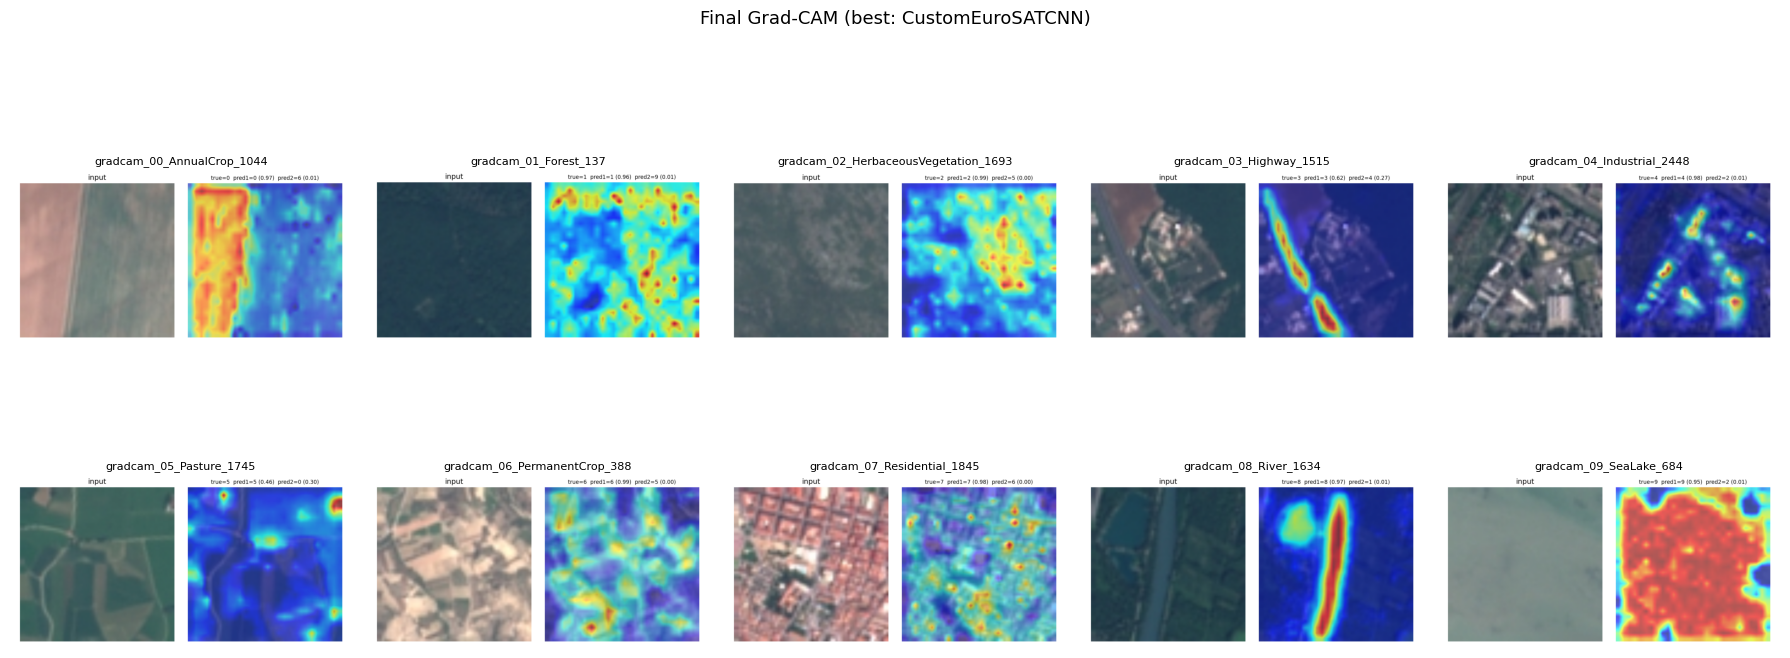


All outputs saved under: /kaggle/working/outputs
 - checkpoints
 - checkpoints.json
 - class_overview.png
 - final_gradcam_grid.png
 - final_test
 - history_custom.csv
 - label_map.json
 - predictions
 - samples_per_class
 - split_train.csv
 - split_val.csv
 - test_metrics
 - test_metrics.csv
 - val_metrics.csv
 - xai
 - xai_report.csv
 - xai_sample_set.csv


In [39]:
best_key  = test_cmp.iloc[0]['model_key']  # only one model, but kept generic
best_ckpt = Path(checkpoints[best_key]['best'])
print('Loading model:', test_cmp.iloc[0]['pretty'], '| ckpt:', best_ckpt)

model, ck = load_model_from_checkpoint(best_ckpt)

final_samples = (
    test_df.groupby(LBL_COL, group_keys=False)
           .apply(lambda g: g.sample(1, random_state=SEED))
           .reset_index(drop=True)
)
final_paths  = final_samples['abs_path'].tolist()
final_labels = final_samples['label_idx'].tolist()

@torch.no_grad()
def predict_top2(model, paths):
    pil = [read_tif_as_rgb(p) for p in paths]
    xb = torch.stack([eval_tfms(im) for im in pil]).to(DEVICE)
    logits = model(xb)
    idx2, prob2 = topk_predictions(logits, 2)
    out = []
    for i, p in enumerate(paths):
        out.append({
            'path':       p,
            'top1':       idx_to_class[int(idx2[i, 0].item())],
            'top1_prob':  float(prob2[i, 0].item()),
            'top2':       idx_to_class[int(idx2[i, 1].item())],
            'top2_prob':  float(prob2[i, 1].item()),
        })
    return out

preds = predict_top2(model, final_paths)
for r, t in zip(preds, final_labels):
    r['true_label'] = idx_to_class[t]
pred_df = pd.DataFrame(preds)
pred_df.to_csv(FINAL_DIR / 'final_predictions.csv', index=False)
print(pred_df.to_string(index=False))

# Final XAI on these per-class samples
try:
    gradcam_explain(model, ck['model_name'], final_paths,
                    FINAL_DIR / 'gradcam', true_labels=final_labels)
    print('Final Grad-CAM ok.')
except Exception as e:
    print('Final Grad-CAM failed:', e)

try:
    lime_explain(model, best_key, final_paths, FINAL_DIR / 'lime',
                 max_images=len(final_paths), true_labels=final_labels)
    print('Final LIME ok.')
except Exception as e:
    print('Final LIME failed:', e)

# Mosaic preview
g_files = sorted((FINAL_DIR / 'gradcam').glob('*.png'))
if g_files:
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    axes = axes.reshape(-1)
    for i, ax in enumerate(axes):
        if i < len(g_files):
            ax.imshow(Image.open(g_files[i])); ax.set_title(g_files[i].stem, fontsize=8)
        ax.axis('off')
    fig.suptitle(f"Final Grad-CAM (best: {ck['pretty']})", fontsize=13)
    fig.tight_layout(); fig.savefig(OUT_DIR / 'final_gradcam_grid.png', dpi=150)
    plt.show()

del model
if torch.cuda.is_available(): torch.cuda.empty_cache()

print('\nAll outputs saved under:', OUT_DIR)
for p in sorted(OUT_DIR.iterdir()):
    print(' -', p.name)

In [40]:
import shutil

# Zip the entire working directory
shutil.make_archive('/kaggle/working/my_output', 'zip', '/kaggle/working')

print("Zipped successfully!")

Zipped successfully!


In [42]:
import os
import zipfile

zip_path = "/kaggle/working/full_output.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files in os.walk("/kaggle/working"):
        for file in files:
            file_path = os.path.join(root, file)
            
            # Avoid zipping the zip itself (important)
            if file_path == zip_path:
                continue
                
            arcname = os.path.relpath(file_path, "/kaggle/working")
            z.write(file_path, arcname)

print("✅ ZIP created at:", zip_path)

✅ ZIP created at: /kaggle/working/full_output.zip
